In [1]:

# azureml-core of version 1.0.72 or higher is required
# azureml-dataprep[pandas] of version 1.1.34 or higher is required
from azureml.core import Workspace, Dataset

subscription_id = 'be34845d-449d-4f47-89be-d6776438dd0e'
resource_group = 'cmr'
workspace_name = 'cmrmlo'

workspace = Workspace(subscription_id, resource_group, workspace_name)

dataset = Dataset.get_by_name(workspace, name='loan')
dataset.to_pandas_dataframe()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.8.1) and child packages mlflow-skinny (3.5.0) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,False,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,True,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,False,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,False,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,False,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,False,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,False,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,False,1


{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
Dataset Loaded Successfully
Shape: (45000, 14)
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL     

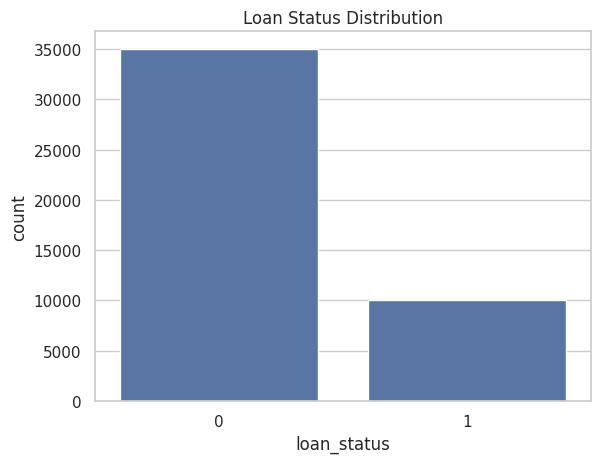

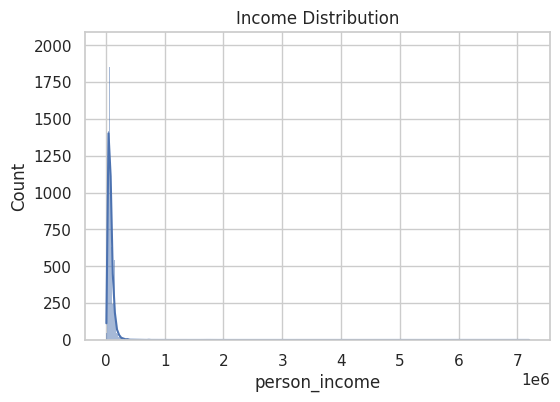

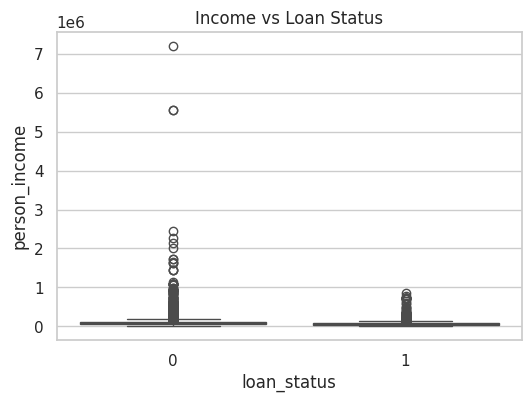

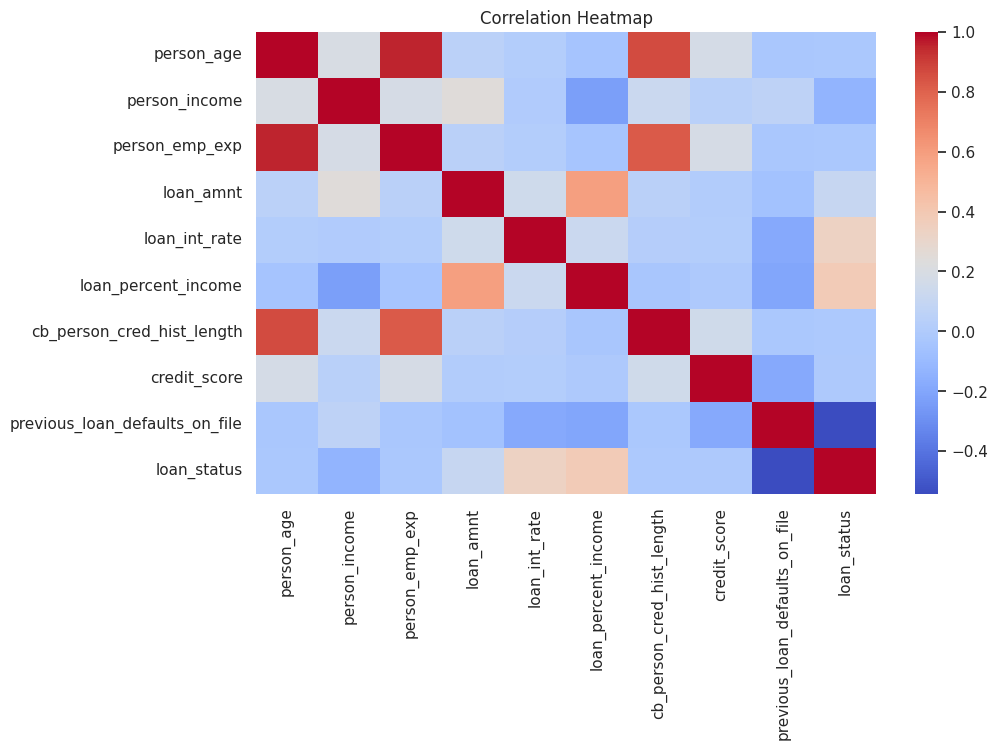


===== LOGISTIC REGRESSION =====
Accuracy: 0.8971111111111111
Precision: 0.7841269841269841
Recall: 0.741
F1 Score: 0.7619537275064268
AUC: 0.9542071746031746

===== KNN (k=3) =====
Accuracy: 0.8794074074074074
Precision: 0.7552083333333334
Recall: 0.6766666666666666
F1 Score: 0.7137834036568214

===== KNN (k=5) =====
Accuracy: 0.886962962962963
Precision: 0.7913043478260869
Recall: 0.6673333333333333
F1 Score: 0.7240506329113924

===== DECISION TREE =====
Accuracy: 0.9103703703703704
Precision: 0.8582866293034428
Recall: 0.7146666666666667
F1 Score: 0.7799199708985085


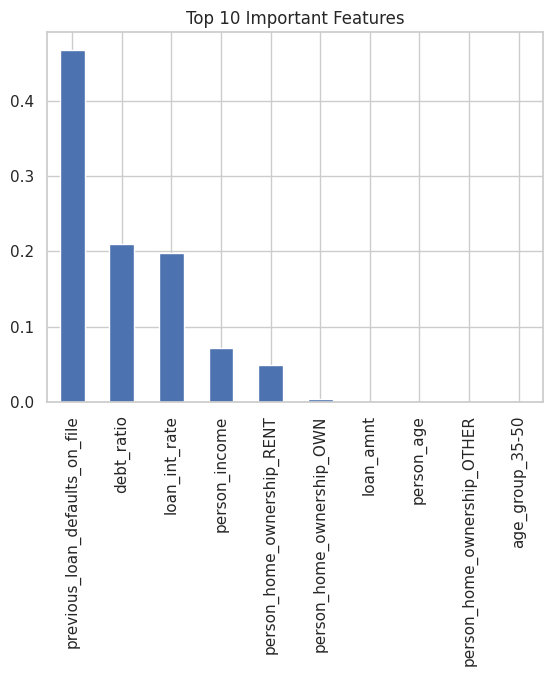

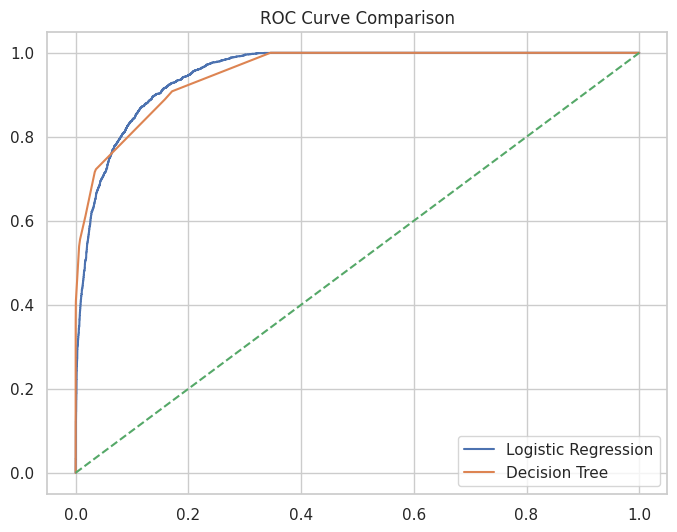


Model Comparison:
                  Model  Accuracy
0  Logistic Regression  0.897111
1        Decision Tree  0.910370

Best model saved as loan_model.pkl

================ BUSINESS INSIGHTS ================
1. Higher income significantly increases loan approval probability.
2. Credit score is one of the strongest predictors.
3. Previous defaults reduce approval chances.
4. High debt ratio increases rejection risk.
5. Bank should target stable income + high credit score customers.


In [5]:
# ==============================================================
# LOAN STATUS PREDICTION PROJECT - AZURE ML VERSION
# ==============================================================

# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from azureml.core import Workspace, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import joblib

sns.set(style="whitegrid")

# ==============================
# 2. LOAD DATA FROM AZURE
# ==============================

subscription_id = 'be34845d-449d-4f47-89be-d6776438dd0e'
resource_group = 'cmr'
workspace_name = 'cmrmlo'

ws = Workspace(subscription_id, resource_group, workspace_name)

dataset = Dataset.get_by_name(ws, name='loan')
df = dataset.to_pandas_dataframe()

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print(df.head())

# ==============================
# 3. DATA CLEANING
# ==============================

# Remove duplicates
df = df.drop_duplicates()

# Convert boolean to int
df["previous_loan_defaults_on_file"] = df["previous_loan_defaults_on_file"].astype(int)

# Fix negative employment experience (if any)
df["person_emp_exp"] = df["person_emp_exp"].abs()

print("\nMissing Values:\n", df.isnull().sum())

# ==============================
# 4. TARGET ANALYSIS
# ==============================

print("\nLoan Status Distribution:\n", df["loan_status"].value_counts())

sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

# ==============================
# 5. EDA
# ==============================

plt.figure(figsize=(6,4))
sns.histplot(df["person_income"], kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="loan_status", y="person_income", data=df)
plt.title("Income vs Loan Status")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 6. FEATURE ENGINEERING
# ==============================

# Debt Ratio
df["debt_ratio"] = df["loan_amnt"] / (df["person_income"] + 1)

# Income per Experience
df["income_exp_ratio"] = df["person_income"] / (df["person_emp_exp"] + 1)

# Age Group
df["age_group"] = pd.cut(df["person_age"],
                         bins=[18,25,35,50,70],
                         labels=["18-25","25-35","35-50","50+"])

# Encode categorical features
df = pd.get_dummies(df, drop_first=True)

# ==============================
# 7. TRAIN TEST SPLIT
# ==============================

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 8. LOGISTIC REGRESSION
# ==============================

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

# ==============================
# 9. KNN
# ==============================

for k in [3,5]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)

    print(f"\n===== KNN (k={k}) =====")
    print("Accuracy:", accuracy_score(y_test, y_pred_knn))
    print("Precision:", precision_score(y_test, y_pred_knn))
    print("Recall:", recall_score(y_test, y_pred_knn))
    print("F1 Score:", f1_score(y_test, y_pred_knn))

# ==============================
# 10. DECISION TREE
# ==============================

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\n===== DECISION TREE =====")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

# Feature Importance
importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

# ==============================
# 11. ROC CURVE COMPARISON
# ==============================

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:,1])
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

# ==============================
# 12. MODEL COMPARISON
# ==============================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ]
})

print("\nModel Comparison:\n", results)

# ==============================
# 13. SAVE BEST MODEL
# ==============================

joblib.dump(lr, "loan_model.pkl")
print("\nBest model saved as loan_model.pkl")

# ==============================
# 14. BUSINESS INSIGHTS
# ==============================

print("\n================ BUSINESS INSIGHTS ================")
print("1. Higher income significantly increases loan approval probability.")
print("2. Credit score is one of the strongest predictors.")
print("3. Previous defaults reduce approval chances.")
print("4. High debt ratio increases rejection risk.")
print("5. Bank should target stable income + high credit score customers.")
print("===================================================")